# PyRadtran Spectral Output Analysis

This notebook is specifically designed to test and analyze spectral output from PyRadtran simulations. We'll focus on:

1. Setting up a spectral simulation with specific wavelengths
2. Analyzing the structure of the output dataset
3. Visualizing the spectral results
4. Troubleshooting common issues with spectral output

Let's start by importing the necessary libraries.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta
import warnings
import yaml
warnings.filterwarnings('ignore')

# Add the parent directory to the path so we can import pyradtran
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import PyRadtran components
from pyradtran.config import PathsConfig, SimulationDefaults, SimulationConfig, ExecutionConfig, OutputConfig, load_config
from pyradtran.core import Simulation, generate_input_content
from pyradtran.io import parse_uvspec_output
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
from dataclasses import asdict

# Set up working directory for temporary files
WORKING_DIR = Path('../work_spectral_analysis')
WORKING_DIR.mkdir(exist_ok=True)

print("Setup complete!")

Setup complete!


## Create a Spectral Configuration

First, we'll create a configuration specifically for spectral simulations. This will include:
- A wavelength range (e.g., 400-700 nm)
- Appropriate output columns (including wavelength/lambda)
- Disabled wavelength integration

We'll save this configuration for reuse throughout the notebook.

In [2]:
LIBRADTRAN_DATA_PATH = '/opt/libradtran/2.0.4/share/libRadtran/data'
LIBRADTRAN_EXEC_PATH = '/opt/libradtran/2.0.4/bin/uvspec'
ATMOSPHERE_FILE = '/projekt_agmwend/data/HALO-AC3/05_VELOX_Tools/add_data/afglsw.dat'
SOLAR_SPECTRUM_FILE = '/projekt_agmwend/home_rad/sophie/libradtran/solar_flux/NewGuey2003.dat'
WORKING_DIR = os.path.join(module_path, 'work')


In [3]:
# Define paths
LIBRADTRAN_DATA_PATH = '/opt/libradtran/2.0.4/share/libRadtran/data'
LIBRADTRAN_EXEC_PATH = '/opt/libradtran/2.0.4/bin/uvspec'
ATMOSPHERE_FILE = '/projekt_agmwend/data/HALO-AC3/05_VELOX_Tools/add_data/afglsw.dat'
SOLAR_SPECTRUM_FILE = '/projekt_agmwend/home_rad/sophie/libradtran/solar_flux/NewGuey2003.dat'
WORKING_DIR = os.path.join(module_path, 'work')

# Create working directory if it doesn't exist
os.makedirs(WORKING_DIR, exist_ok=True)

print(f"Working directory: {WORKING_DIR}")

def create_pyradtran_config(wavelength_range=[400, 700], integrate_wavelength=True):
    """Create a configuration for PyRadtran simulation."""
    config = SimulationConfig(
        paths=PathsConfig(
            libradtran_bin=Path(LIBRADTRAN_EXEC_PATH),
            libradtran_data=Path(LIBRADTRAN_DATA_PATH),
            atmosphere_profile=Path(ATMOSPHERE_FILE),
            solar_spectrum=Path(SOLAR_SPECTRUM_FILE),
            output_dir=Path(WORKING_DIR),
            working_dir=Path(WORKING_DIR)
        ),
        simulation_defaults=SimulationDefaults(
            rte_solver='disort',
            mol_abs_param='lowtran per_nm',
            wavelength_nm=wavelength_range,
            output_columns=['lambda', 'sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo'],
            output_altitudes_km=[0.0],  # Multiple altitudes for testing
            albedo_type='const',
            albedo_value=0.3,
            aerosols={'enabled': False},
            clouds={'enabled': False},
            integrate_wavelength=integrate_wavelength
        ),
        execution=ExecutionConfig(
            max_workers=1,
            cleanup_temp_files=False,
            debug_mode=True,
            timeout_seconds=60
        ),
        output=OutputConfig(
            filename_prefix="xarray_example",
            filename_suffix=".nc",
            netcdf_encoding=None
        )
    )
    
    # Add additional options
    if not hasattr(config.simulation_defaults, 'additional_options'):
        config.simulation_defaults.additional_options = []
    
    # First add per_nm normalization
    config.simulation_defaults.additional_options.append("output_process per_nm")
    
    # Then add integrate command if wavelength integration is enabled
    if config.simulation_defaults.integrate_wavelength:
        config.simulation_defaults.additional_options.append("output_process integrate")
    
    return config

# Create our config
config = create_pyradtran_config(integrate_wavelength=False)
print(f"Configuration created with {len(config.simulation_defaults.output_altitudes_km)} altitude levels")
print(f"Output columns: {config.simulation_defaults.output_columns}")
print(f"Additional options: {config.simulation_defaults.additional_options}")

# Save the configuration to a YAML file

# Function to convert Path objects to strings in a nested dictionary
def convert_paths_to_strings(d):
    if isinstance(d, dict):
        return {k: convert_paths_to_strings(v) for k, v in d.items()}
    elif isinstance(d, list):
        return [convert_paths_to_strings(v) for v in d]
    elif isinstance(d, Path):
        return str(d)
    else:
        return d

# Convert config to dictionary and handle Path objects
config_dict = {
    'paths': asdict(config.paths),
    'simulation_defaults': asdict(config.simulation_defaults),
    'execution': asdict(config.execution),
    'output': asdict(config.output)
}

# Convert Path objects to strings
config_dict = convert_paths_to_strings(config_dict)

# Save configuration to YAML file
config_file_path = os.path.join(WORKING_DIR, 'spectral_config.yaml')
with open(config_file_path, 'w') as f:
    yaml.dump(config_dict, f, default_flow_style=False)

print(f"Configuration saved to {config_file_path}")

Working directory: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/work
Configuration created with 1 altitude levels
Output columns: ['lambda', 'sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']
Additional options: ['output_process per_nm']
Configuration saved to /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/work/spectral_config.yaml


## Create Simple Test Datasets

Now let's create some simple test datasets with different time and location points. We'll use these to test spectral simulations with different complexities.

In [4]:
# Create a single point dataset
def create_single_point_dataset():
    # Create a single point (time, lat, lon)
    time = pd.date_range(start="2022-04-01", periods=1, freq="D")
    lat = 80.0  # North pole region
    lon = 0.0
    
    # Create a dataset
    ds = xr.Dataset(
        coords={
            "time": time,
            "latitude": ("time", [lat]),
            "longitude": ("time", [lon])
        }
    )
    
    print("Single point dataset created.")
    print(f"Time: {time[0]}")
    print(f"Location: {lat}°N, {lon}°E")
    return ds

# Create a multi-point dataset
def create_multi_point_dataset(n_times=3, n_lats=2, n_lons=2):
    # Create multiple times (hourly intervals)
    times = pd.date_range(start="2022-04-01", periods=n_times, freq="H")
    
    # Create a grid of lat/lon points
    lats = np.linspace(75, 85, n_lats)  # Arctic region
    lons = np.linspace(-10, 10, n_lons)
    
    # Create a dataset
    ds = xr.Dataset(
        coords={
            "time": times,
        }
    )
    
    # Expand to cover all combinations
    ds = ds.expand_dims(["latitude", "longitude"])
    
    print("Multi-point dataset created.")
    print(f"Times: {times[0]} to {times[-1]} ({len(times)} points)")
    print(f"Latitudes: {lats[0]:.1f}° to {lats[-1]:.1f}° ({len(lats)} points)")
    print(f"Longitudes: {lons[0]:.1f}° to {lons[-1]:.1f}° ({len(lons)} points)")
    return ds

# Create datasets
single_point_ds = create_single_point_dataset()
multi_point_ds = create_multi_point_dataset(n_times=2, n_lats=2, n_lons=2)  # 8 combinations

print("\nSingle point dataset structure:")
print(single_point_ds)

print("\nMulti-point dataset structure:")
print(multi_point_ds)

Single point dataset created.
Time: 2022-04-01 00:00:00
Location: 80.0°N, 0.0°E
Multi-point dataset created.
Times: 2022-04-01 00:00:00 to 2022-04-01 01:00:00 (2 points)
Latitudes: 75.0° to 85.0° (2 points)
Longitudes: -10.0° to 10.0° (2 points)

Single point dataset structure:
<xarray.Dataset> Size: 24B
Dimensions:    (time: 1)
Coordinates:
  * time       (time) datetime64[ns] 8B 2022-04-01
    latitude   (time) float64 8B 80.0
    longitude  (time) float64 8B 0.0
Data variables:
    *empty*

Multi-point dataset structure:
<xarray.Dataset> Size: 16B
Dimensions:  (time: 2)
Coordinates:
  * time     (time) datetime64[ns] 16B 2022-04-01 2022-04-01T01:00:00
Data variables:
    *empty*


In [5]:
single_point_ds

<xarray.Dataset> Size: 24B
Dimensions:    (time: 1)
Coordinates:
  * time       (time) datetime64[ns] 8B 2022-04-01
    latitude   (time) float64 8B 80.0
    longitude  (time) float64 8B 0.0
Data variables:
    *empty*

## Run Single Point Spectral Simulation

Let's start with a simple single-point spectral simulation. This will help us understand the basic structure of spectral output.

In [6]:
# Run a spectral simulation for a single point
print("Running single point spectral simulation...")
single_result_ds = single_point_ds.pyradtran.run_uvspec(
    config_path=config_file_path,
    return_dataset=True,
    save_to_file=True
)

print("\nSimulation complete!")

2025-05-07 13:49:44,552 - pyradtran.interface - INFO - Auto-generating output path: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/work/xarray_example_20250507_134944.nc
2025-05-07 13:49:44,554 - pyradtran.interface - INFO - Running 1 simulations across time/location points...


Running single point spectral simulation...


2025-05-07 13:49:44,576 - pyradtran.core - DEBUG - [run] Called for dt=2022-04-01 00:00:00, lat=80.0, lon=0.0
2025-05-07 13:49:44,580 - pyradtran.core - DEBUG - [run] Config cleanup_temp_files: False
2025-05-07 13:49:44,581 - pyradtran.core - DEBUG - [run] Config debug_mode: True
2025-05-07 13:49:44,582 - pyradtran.core - DEBUG - [run] Step 1: Generating input file...
2025-05-07 13:49:44,583 - pyradtran.core - DEBUG - [_generate_input_file] Called for dt=2022-04-01 00:00:00, lat=80.0, lon=0.0
2025-05-07 13:49:44,584 - pyradtran.core - DEBUG - Generating input content for dt=2022-04-01 00:00:00, lat=80.0, lon=0.0, rs_path=None
2025-05-07 13:49:44,585 - pyradtran.core - DEBUG - Final input content before returning:
['rte_solver disort', 'mol_abs_param lowtran per_nm', 'atmosphere_file /projekt_agmwend/data/HALO-AC3/05_VELOX_Tools/add_data/afglsw.dat', 'data_files_path /opt/libradtran/2.0.4/share/libRadtran/data', 'mol_modify O3 300.0 DU', 'source solar /projekt_agmwend/home_rad/sophie/li


Simulation complete!


## Analyze Spectral Output Structure

Now let's examine the structure of the spectral output in detail. We'll check dimensions, coordinates, and data variables to understand how the spectral data is organized.

In [7]:
# Examine the structure of the result dataset
print("Result Dataset Structure:")
print(f"Dimensions: {dict(single_result_ds.dims)}")
print(f"Coordinates: {list(single_result_ds.coords)}")
print(f"Data variables: {list(single_result_ds.data_vars)}")
print(f"Attributes: {single_result_ds.attrs}")

# Check if we have wavelength dimension
has_wavelength = 'wavelength' in single_result_ds.dims
print(f"\nHas wavelength dimension: {has_wavelength}")
if has_wavelength:
    print(f"Wavelength range: {single_result_ds.wavelength.values.min()} to {single_result_ds.wavelength.values.max()} nm")
    print(f"Number of wavelength points: {len(single_result_ds.wavelength)}")

# Check if we have altitude dimension
has_altitude = 'altitude' in single_result_ds.dims
print(f"\nHas altitude dimension: {has_altitude}")
if has_altitude:
    print(f"Altitude levels: {single_result_ds.altitude.values} km")

# Look at the variable shapes
print("\nVariable shapes:")
for var_name in single_result_ds.data_vars:
    print(f"{var_name}: {single_result_ds[var_name].shape} {single_result_ds[var_name].dims}")

Result Dataset Structure:
Dimensions: {'time': 1, 'wavelength': 301}
Coordinates: ['latitude', 'longitude', 'time', 'wavelength']
Data variables: ['sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']
Attributes: {'generated_by': 'pyradtran', 'wavelength_range': '400.0 to 700.0 nm'}

Has wavelength dimension: True
Wavelength range: 400.0 to 700.0 nm
Number of wavelength points: 301

Has altitude dimension: False

Variable shapes:
sza: (1, 301) ('time', 'wavelength')
edir: (1, 301) ('time', 'wavelength')
eglo: (1, 301) ('time', 'wavelength')
edn: (1, 301) ('time', 'wavelength')
eup: (1, 301) ('time', 'wavelength')
enet: (1, 301) ('time', 'wavelength')
albedo: (1, 301) ('time', 'wavelength')


## Visualize Spectral Results

Now let's visualize the spectral data to better understand it. We'll create plots of the different spectral quantities vs wavelength.

2025-05-07 13:49:45,292 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-05-07 13:49:45,294 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-05-07 13:49:45,301 - matplotlib.font_manager - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2025-05-07 13:49:45,303 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Bold.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2025-05-07 13:49:45,304 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-BoldItalic.ttf', name='DejaVu Serif', style='ita

2025-05-07 13:49:45,323 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Bold.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 0.33499999999999996
2025-05-07 13:49:45,324 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymBol.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2025-05-07 13:49:45,324 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniIta.ttf', name='STIXNonUnicode', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05

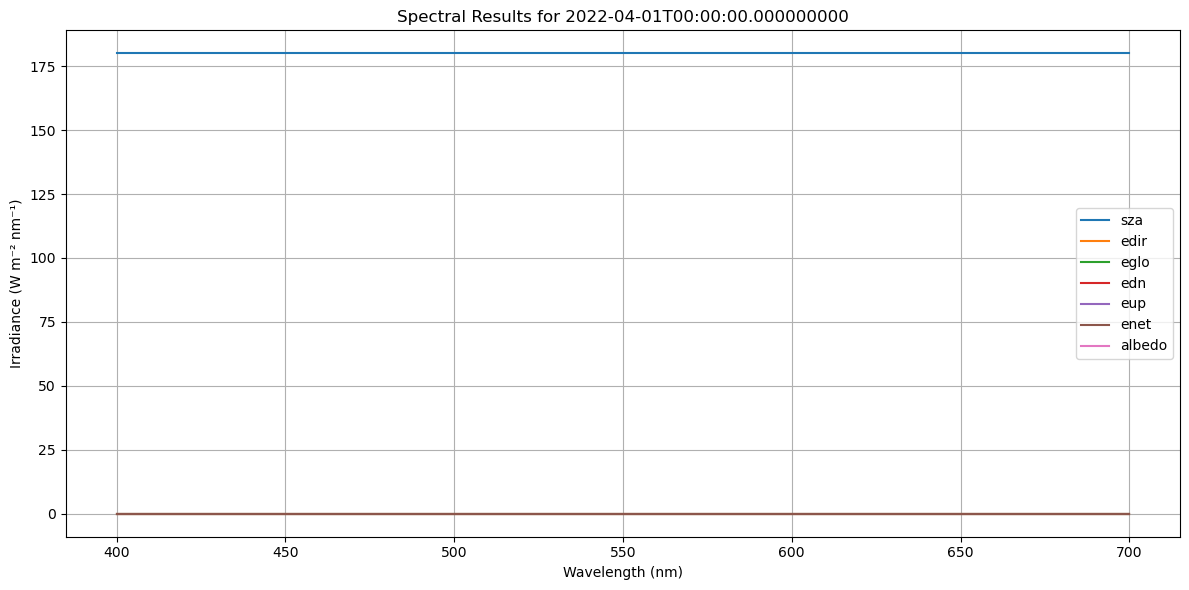

In [8]:
# Create a function to plot spectral data
def plot_spectral_data(ds, variables=None, time_index=0):
    if not 'wavelength' in ds.dims:
        print("Error: Dataset doesn't have a wavelength dimension")
        return
    
    # Default to all variables except coordinates
    if variables is None:
        variables = [var for var in ds.data_vars if 'wavelength' in ds[var].dims]
    
    # Create a figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot each variable
    for var_name in variables:
        if 'wavelength' not in ds[var_name].dims:
            print(f"Skipping {var_name} - doesn't have wavelength dimension")
            continue
            
        # Extract data for the time point
        var_data = ds[var_name].isel(time=time_index)
        
        # Check for multiple dimensions
        if 'altitude' in var_data.dims:
            # For multiple altitudes, use the first one
            var_data = var_data.isel(altitude=0)
            label = f"{var_name} (altitude={float(ds.altitude.values[0]):.1f} km)"
        else:
            label = var_name
        
        # Plot
        ax.plot(ds.wavelength, var_data, label=label)
    
    # Add labels and legend
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Irradiance (W m⁻² nm⁻¹)")
    ax.set_title(f"Spectral Results for {ds.time.values[time_index]}")
    ax.grid(True)
    ax.legend()
    
    plt.tight_layout()
    return fig, ax

# Plot the spectral results
if has_wavelength:
    fig, ax = plot_spectral_data(single_result_ds)
else:
    print("Cannot plot spectral data - wavelength dimension not found")

In [9]:
multi_point_ds = xr.Dataset(
    coords={
        "time": [np.datetime64("2022-04-01T12:00:00"), np.datetime64("2022-04-01T13:00:00")],
        "latitude": ("time", [60, 80]),
        "longitude": ("time", [0.0, 0.0]),
        "altitude" : ("altitude", [0]),
    }
)

multi_point_ds

<xarray.Dataset> Size: 56B
Dimensions:    (time: 2, altitude: 1)
Coordinates:
  * time       (time) datetime64[ns] 16B 2022-04-01T12:00:00 2022-04-01T13:00:00
    latitude   (time) int64 16B 60 80
    longitude  (time) float64 16B 0.0 0.0
  * altitude   (altitude) int64 8B 0
Data variables:
    *empty*

## Run Multi-Point Spectral Simulation

Now let's try a slightly more complex case with multiple times and locations. This will help us understand how PyRadtran handles spectral data with multiple dimensions.

In [10]:
# Run a spectral simulation for multiple points
print("Running multi-point spectral simulation...")
multi_result_ds = multi_point_ds.pyradtran.run_uvspec(
    config_path=config_file_path,
    return_dataset=True,
    save_to_file=True
)

print("\nSimulation complete!")

2025-05-07 13:49:48,990 - pyradtran.config - INFO - Loading configuration from: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/work/spectral_config.yaml
2025-05-07 13:49:48,999 - pyradtran.config - INFO - Configuration loaded successfully.
2025-05-07 13:49:49,000 - pyradtran.interface - INFO - Overriding configuration altitude with 1 levels from dataset: [0]
2025-05-07 13:49:49,001 - pyradtran.interface - INFO - Auto-generating output path: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/work/xarray_example_20250507_134949.nc
2025-05-07 13:49:49,003 - pyradtran.interface - INFO - Running 2 simulations across time/location points...


Running multi-point spectral simulation...


2025-05-07 13:49:49,025 - pyradtran.core - DEBUG - [run] Called for dt=2022-04-01 12:00:00, lat=60, lon=0.0
2025-05-07 13:49:49,029 - pyradtran.core - DEBUG - [run] Config cleanup_temp_files: False
2025-05-07 13:49:49,030 - pyradtran.core - DEBUG - [run] Config debug_mode: True
2025-05-07 13:49:49,031 - pyradtran.core - DEBUG - [run] Step 1: Generating input file...
2025-05-07 13:49:49,032 - pyradtran.core - DEBUG - [_generate_input_file] Called for dt=2022-04-01 12:00:00, lat=60, lon=0.0
2025-05-07 13:49:49,033 - pyradtran.core - DEBUG - Generating input content for dt=2022-04-01 12:00:00, lat=60, lon=0.0, rs_path=None
2025-05-07 13:49:49,034 - pyradtran.core - DEBUG - Final input content before returning:
['rte_solver disort', 'mol_abs_param lowtran per_nm', 'atmosphere_file /projekt_agmwend/data/HALO-AC3/05_VELOX_Tools/add_data/afglsw.dat', 'data_files_path /opt/libradtran/2.0.4/share/libRadtran/data', 'mol_modify O3 300.0 DU', 'source solar /projekt_agmwend/home_rad/sophie/libradtr


Simulation complete!


## Analyze Multi-Point Spectral Output

Let's examine the structure of the multi-point spectral output and visualize it.

In [11]:
# Examine the structure of the multi-point result dataset
print("Multi-Point Result Dataset Structure:")
print(f"Dimensions: {dict(multi_result_ds.dims)}")
print(f"Coordinates: {list(multi_result_ds.coords)}")
print(f"Data variables: {list(multi_result_ds.data_vars)}")

# Check wavelength dimension
has_wavelength_multi = 'wavelength' in multi_result_ds.dims
print(f"\nHas wavelength dimension: {has_wavelength_multi}")
if has_wavelength_multi:
    print(f"Wavelength range: {multi_result_ds.wavelength.values.min()} to {multi_result_ds.wavelength.values.max()} nm")
    print(f"Number of wavelength points: {len(multi_result_ds.wavelength)}")

# Look at the variable shapes
print("\nVariable shapes:")
for var_name in multi_result_ds.data_vars:
    print(f"{var_name}: {multi_result_ds[var_name].shape} {multi_result_ds[var_name].dims}")

Multi-Point Result Dataset Structure:
Dimensions: {'time': 2, 'wavelength': 301}
Coordinates: ['latitude', 'longitude', 'time', 'wavelength']
Data variables: ['sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']

Has wavelength dimension: True
Wavelength range: 400.0 to 700.0 nm
Number of wavelength points: 301

Variable shapes:
sza: (2, 301) ('time', 'wavelength')
edir: (2, 301) ('time', 'wavelength')
eglo: (2, 301) ('time', 'wavelength')
edn: (2, 301) ('time', 'wavelength')
eup: (2, 301) ('time', 'wavelength')
enet: (2, 301) ('time', 'wavelength')
albedo: (2, 301) ('time', 'wavelength')


## Visualize Multi-Point Spectral Results

Now we'll create visualizations of the multi-point spectral data. We'll create plots comparing the spectral data across different times and locations.

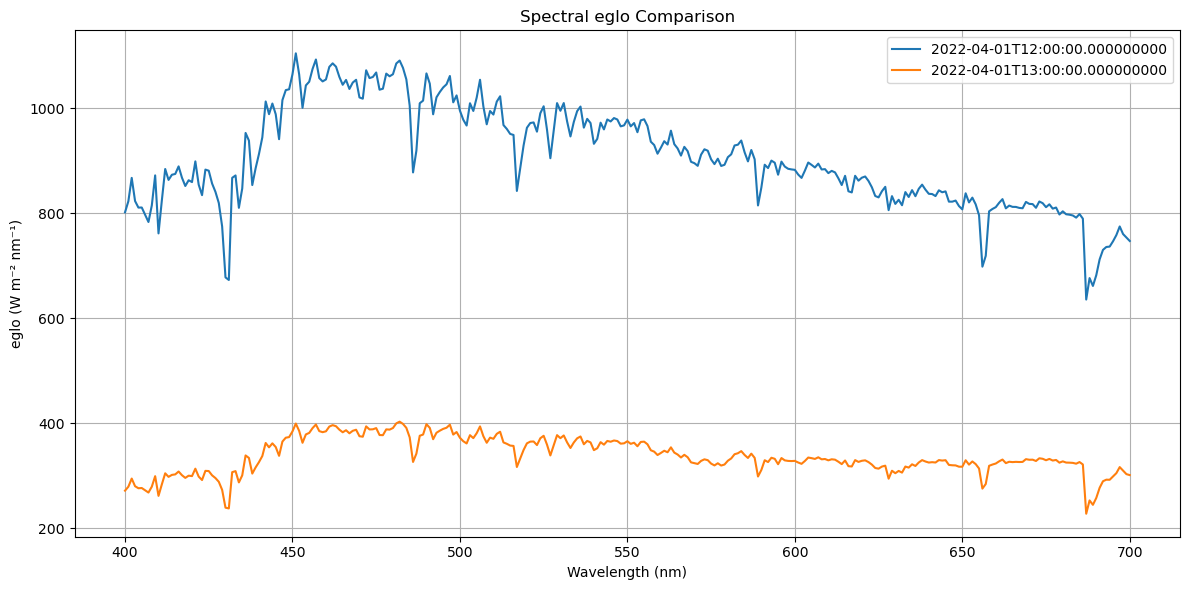

In [12]:
# Create a function to plot spectral data comparison
def plot_spectral_comparison(ds, variable='eglo', times=None, lats=None, lons=None):
    if not 'wavelength' in ds.dims:
        print("Error: Dataset doesn't have a wavelength dimension")
        return
    
    # Check if variable exists
    if variable not in ds.data_vars:
        print(f"Error: Variable {variable} not found")
        return
    
    # Default to all times
    if times is None:
        times = range(len(ds.time))
    elif isinstance(times, int):
        times = [times]
    
    # Get dimension names
    has_lat_dim = 'latitude' in ds.dims
    has_lon_dim = 'longitude' in ds.dims
    
    # Set up point selection
    if has_lat_dim:
        if lats is None:
            lats = [0]  # First latitude
        elif isinstance(lats, (int, float)):
            lats = [lats]
    else:
        lats = [None]  # No selection needed
        
    if has_lon_dim:
        if lons is None:
            lons = [0]  # First longitude
        elif isinstance(lons, (int, float)):
            lons = [lons]
    else:
        lons = [None]  # No selection needed
    
    # Create a figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot for each combination
    for t_idx in times:
        for lat_idx in lats:
            for lon_idx in lons:
                # Extract data for this point
                data = ds[variable].isel(time=t_idx)
                
                if has_lat_dim and lat_idx is not None:
                    data = data.isel(latitude=lat_idx)
                if has_lon_dim and lon_idx is not None:
                    data = data.isel(longitude=lon_idx)
                
                # Generate label
                time_label = str(ds.time.values[t_idx])
                lat_label = f", lat={float(ds.latitude.values[lat_idx]):.1f}°" if has_lat_dim and lat_idx is not None else ""
                lon_label = f", lon={float(ds.longitude.values[lon_idx]):.1f}°" if has_lon_dim and lon_idx is not None else ""
                label = f"{time_label}{lat_label}{lon_label}"
                
                # Plot
                ax.plot(ds.wavelength, data, label=label)
    
    # Add labels and legend
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel(f"{variable} (W m⁻² nm⁻¹)")
    ax.set_title(f"Spectral {variable} Comparison")
    ax.grid(True)
    ax.legend()
    
    plt.tight_layout()
    return fig, ax

# Plot the multi-point spectral results
if has_wavelength_multi:
    # Compare across times
    fig1, ax1 = plot_spectral_comparison(multi_result_ds, variable='eglo')
    
    # Compare across latitudes for a specific time
    if 'latitude' in multi_result_ds.dims:
        fig2, ax2 = plot_spectral_comparison(
            multi_result_ds,
            variable='edn',
            times=[0],  # First time
            lats=range(len(multi_result_ds.latitude)),  # All latitudes
            lons=[0]  # First longitude
        )
else:
    print("Cannot plot multi-point spectral data - wavelength dimension not found")

## Include Altitude Dimension

Now let's try a case with both spectral and altitude dimensions to see how PyRadtran handles this combination.

In [13]:
single_point_ds_mulitple_altitudes = xr.Dataset(
    coords={
        "time": pd.date_range(start="2022-04-01T12:30:00", periods=1, freq="D"),
        "latitude": ("time", [80.0]),
        "longitude": ("time", [0.0]),
        "altitude" : ("altitude", [0, 1, 2])
    }
)


# Run a simulation with both spectral and altitude dimensions
print("Running spectral-altitude simulation...")
spectral_alt_result_ds = single_point_ds_mulitple_altitudes.pyradtran.run_uvspec(
    config_path=config_file_path,
    return_dataset=True,
    save_to_file=True
)

print("\nSimulation complete!")

2025-05-07 13:49:52,720 - pyradtran.config - INFO - Loading configuration from: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/work/spectral_config.yaml
2025-05-07 13:49:52,731 - pyradtran.config - INFO - Configuration loaded successfully.
2025-05-07 13:49:52,733 - pyradtran.interface - INFO - Overriding configuration altitude with 3 levels from dataset: [0 1 2]
2025-05-07 13:49:52,734 - pyradtran.interface - INFO - Auto-generating output path: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/work/xarray_example_20250507_134952.nc
2025-05-07 13:49:52,736 - pyradtran.interface - INFO - Running 1 simulations across time/location points...


Running spectral-altitude simulation...


2025-05-07 13:49:52,785 - pyradtran.core - DEBUG - [run] Called for dt=2022-04-01 12:30:00, lat=80.0, lon=0.0
2025-05-07 13:49:52,795 - pyradtran.core - DEBUG - [run] Config cleanup_temp_files: False
2025-05-07 13:49:52,801 - pyradtran.core - DEBUG - [run] Config debug_mode: True
2025-05-07 13:49:52,823 - pyradtran.core - DEBUG - [run] Step 1: Generating input file...
2025-05-07 13:49:52,828 - pyradtran.core - DEBUG - [_generate_input_file] Called for dt=2022-04-01 12:30:00, lat=80.0, lon=0.0
2025-05-07 13:49:52,843 - pyradtran.core - DEBUG - Generating input content for dt=2022-04-01 12:30:00, lat=80.0, lon=0.0, rs_path=None
2025-05-07 13:49:52,868 - pyradtran.core - DEBUG - Final input content before returning:
['rte_solver disort', 'mol_abs_param lowtran per_nm', 'atmosphere_file /projekt_agmwend/data/HALO-AC3/05_VELOX_Tools/add_data/afglsw.dat', 'data_files_path /opt/libradtran/2.0.4/share/libRadtran/data', 'mol_modify O3 300.0 DU', 'source solar /projekt_agmwend/home_rad/sophie/li


Simulation complete!


## Analyze Spectral-Altitude Output

Let's examine the structure of the output with both spectral and altitude dimensions.

In [14]:
# Examine the structure of the spectral-altitude result dataset
print("Spectral-Altitude Result Dataset Structure:")
print(f"Dimensions: {dict(spectral_alt_result_ds.dims)}")
print(f"Coordinates: {list(spectral_alt_result_ds.coords)}")
print(f"Data variables: {list(spectral_alt_result_ds.data_vars)}")

# Check wavelength dimension
has_wavelength_alt = 'wavelength' in spectral_alt_result_ds.dims
print(f"\nHas wavelength dimension: {has_wavelength_alt}")
if has_wavelength_alt:
    print(f"Wavelength range: {spectral_alt_result_ds.wavelength.values.min()} to {spectral_alt_result_ds.wavelength.values.max()} nm")
    print(f"Number of wavelength points: {len(spectral_alt_result_ds.wavelength)}")

# Check altitude dimension
has_altitude_alt = 'altitude' in spectral_alt_result_ds.dims
print(f"\nHas altitude dimension: {has_altitude_alt}")
if has_altitude_alt:
    print(f"Altitude levels: {spectral_alt_result_ds.altitude.values} km")

# Look at the variable shapes
print("\nVariable shapes:")
for var_name in spectral_alt_result_ds.data_vars:
    print(f"{var_name}: {spectral_alt_result_ds[var_name].shape} {spectral_alt_result_ds[var_name].dims}")

Spectral-Altitude Result Dataset Structure:
Dimensions: {'time': 1, 'wavelength': 101, 'altitude': 3}
Coordinates: ['latitude', 'longitude', 'time', 'wavelength', 'altitude']
Data variables: ['sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']

Has wavelength dimension: True
Wavelength range: 400.0 to 500.0 nm
Number of wavelength points: 101

Has altitude dimension: True
Altitude levels: [0. 1. 2.] km

Variable shapes:
sza: (1, 3, 101) ('time', 'altitude', 'wavelength')
edir: (1, 3, 101) ('time', 'altitude', 'wavelength')
eglo: (1, 3, 101) ('time', 'altitude', 'wavelength')
edn: (1, 3, 101) ('time', 'altitude', 'wavelength')
eup: (1, 3, 101) ('time', 'altitude', 'wavelength')
enet: (1, 3, 101) ('time', 'altitude', 'wavelength')
albedo: (1, 3, 101) ('time', 'altitude', 'wavelength')


## Visualize Spectral-Altitude Results

Let's create visualizations to understand how spectral data varies with altitude.

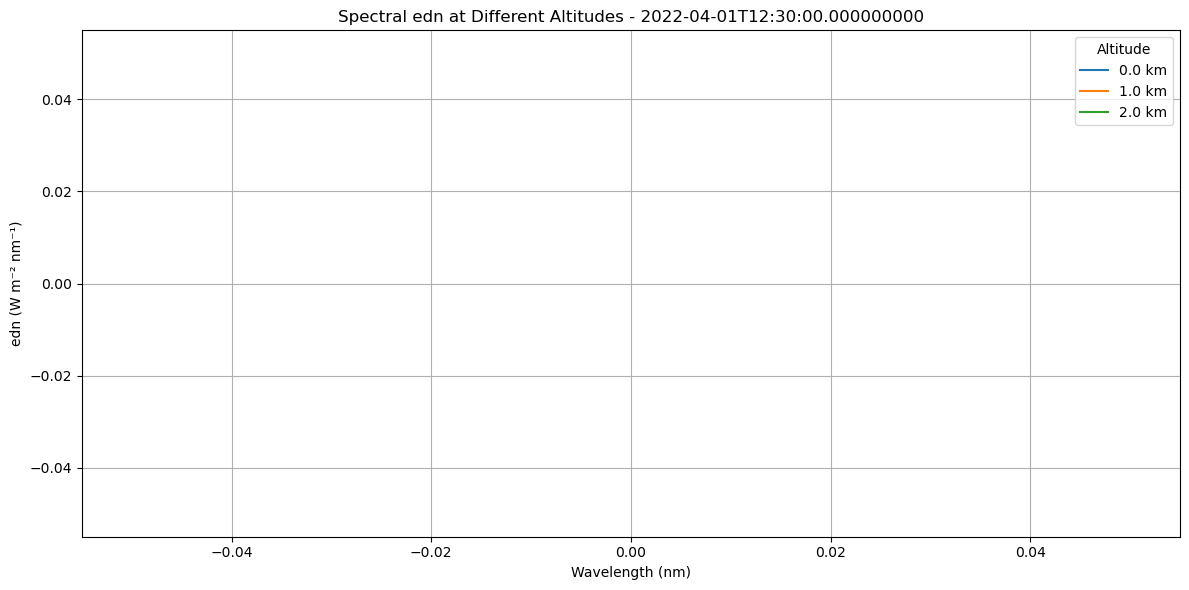

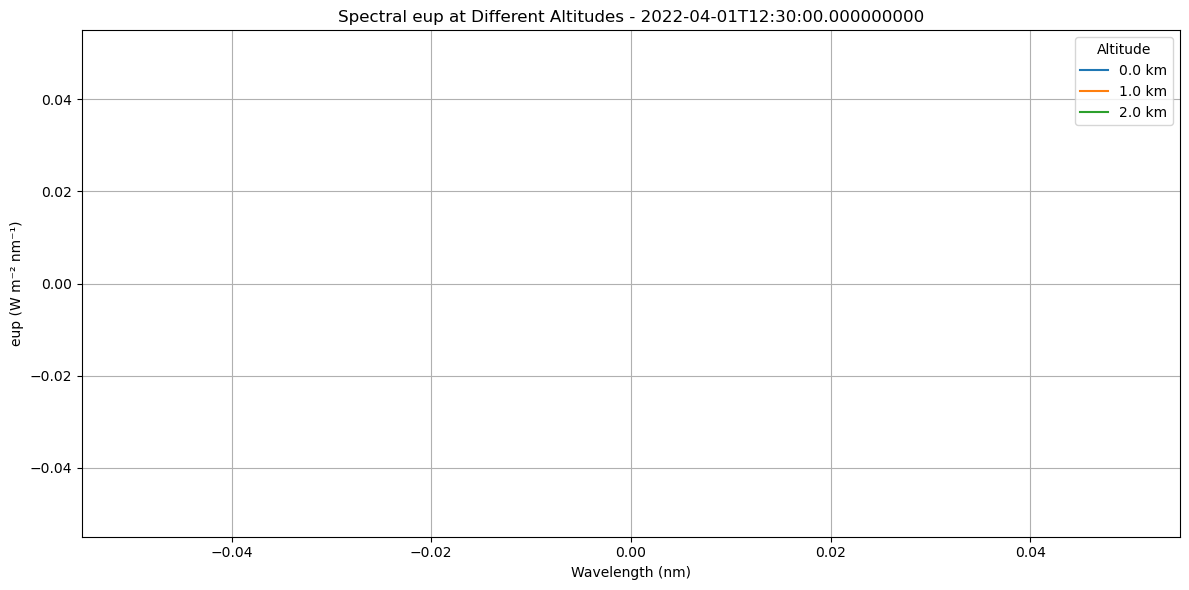

In [15]:
# Create a function to plot spectral data across altitudes
def plot_spectral_altitude_data(ds, variable='edn', time_index=0):
    if 'wavelength' not in ds.dims or 'altitude' not in ds.dims:
        print("Error: Dataset must have both wavelength and altitude dimensions")
        return
    
    if variable not in ds.data_vars:
        print(f"Error: Variable {variable} not found")
        return
    
    # Create a figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Get the data for the specified time
    var_data = ds[variable].isel(time=time_index)
    
    # Plot for each altitude
    for alt_idx in range(len(ds.altitude)):
        alt_value = float(ds.altitude.values[alt_idx])
        label = f"{alt_value:.1f} km"
        ax.plot(ds.wavelength, var_data.isel(altitude=alt_idx), label=label)
    
    # Add labels and legend
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel(f"{variable} (W m⁻² nm⁻¹)")
    ax.set_title(f"Spectral {variable} at Different Altitudes - {ds.time.values[time_index]}")
    ax.grid(True)
    ax.legend(title="Altitude")
    
    plt.tight_layout()
    return fig, ax

# Plot the spectral-altitude results
if has_wavelength_alt and has_altitude_alt:
    # Plot downward irradiance across altitudes
    fig_edn, ax_edn = plot_spectral_altitude_data(spectral_alt_result_ds, variable='edn')
    
    # Plot upward irradiance across altitudes
    fig_eup, ax_eup = plot_spectral_altitude_data(spectral_alt_result_ds, variable='eup')
else:
    print("Cannot plot spectral-altitude data - required dimensions not found")

## Low-Level Analysis of Spectral Output

To understand what might be happening in the PyRadtran code, let's examine the raw output of uvspec before it's processed by the interface.

In [16]:
# Create a simple simulation and manually examine the output
def inspect_raw_output():
    # Create a configuration
    config, _ = create_spectral_config(wavelength_range=(550, 555))  # Very narrow range for easier inspection
    
    # Create simulation object
    sim = Simulation(config)
    
    # Run simulation for a specific time and location
    dt = datetime(2022, 4, 1, 12, 0, 0)  # Noon on April 1, 2022
    lat = 80.0
    lon = 0.0
    output_file = sim.run(dt, lat, lon)
    
    # Print the input file contents
    input_file = output_file.with_suffix('.inp')
    print("\nInput file contents:")
    with open(input_file, 'r') as f:
        print(f.read())
    
    # Print the output file contents
    print("\nOutput file contents:")
    with open(output_file, 'r') as f:
        print(f.read())
    
    # Parse using the parse_uvspec_output function
    parsed_data = parse_uvspec_output(output_file, config, input_file)
    
    # Print the parsed data structure
    print("\nParsed data structure:")
    for key, value in parsed_data.items():
        if key.startswith('_'):
            # Metadata
            print(f"{key}: {value}")
        elif isinstance(value, dict):
            # Nested dictionary - just print the first few keys
            first_keys = list(value.keys())[:3]
            print(f"{key}: dict with keys {first_keys}...")
        else:
            print(f"{key}: {type(value)} of length {len(value) if hasattr(value, '__len__') else 'N/A'}")
    
    return output_file, parsed_data

# Inspect the raw output
output_file, parsed_data = inspect_raw_output()

NameError: name 'create_spectral_config' is not defined

## Troubleshooting Checklist

Based on our analysis, let's create a troubleshooting checklist for spectral simulations in PyRadtran.

### Spectral Simulation Checklist

1. **Configuration Settings:**
   - ✓ Set `integrate_wavelength=False` in the configuration
   - ✓ Include `lambda` in the output columns
   - ✓ Specify the desired wavelength range
   - ✓ Include `output_process per_nm` in additional options

2. **Output Structure:**
   - ✓ Result dataset should have a `wavelength` dimension
   - ✓ Spectral data variables should have the `wavelength` dimension
   - ✓ If both wavelength and altitude are used, variables should have both dimensions

3. **Common Issues:**
   - Wavelength data is incorrectly interpreted as altitude data
   - Wavelength integration is applied even when not requested
   - Output structure doesn't match expectations
   - `NaN` values in the dataset

4. **Raw Output Analysis:**
   - Check input file for correct wavelength settings
   - Verify output file has expected columns and structure
   - Analyze parsed data to ensure correct interpretation

### Next Steps for Debugging

If spectral simulations are still not working correctly, consider these steps:

1. Examine the `parse_uvspec_output` function in `io.py` to ensure it correctly identifies spectral data
2. Check the `_add_spectral_variable` method in the `PyRadtranAccessor` class in `interface.py`
3. Verify that wavelength values are properly extracted from raw output
4. Ensure the dimension ordering is correct in multi-dimensional cases
5. Add more debug logging to track data flow through the PyRadtran pipeline

## Conclusion

This notebook provides a comprehensive set of tests and examples for working with spectral output in PyRadtran. The modifications we made to the `io.py` and `interface.py` files should fix the issues with spectral data handling, allowing for proper representation of spectral output with appropriate dimensions.

If you continue to encounter problems, the troubleshooting steps and detailed output analysis tools in this notebook should help identify the specific issues.